<a href="https://colab.research.google.com/github/jessicali23/229-Project/blob/main/speech_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎙️ Speech Emotion Recognition

Replicates and critically evaluates the CNN-BiLSTM from:
> *Speech emotion recognition with light weight deep neural ensemble model using hand crafted features* (Nature, 2025)

### Sections
1. Setup & Dependencies
2. Google Drive Configuration
3. Download Datasets
4. Explore the Data
5. Feature Extraction & Augmentation
6. Model Training
7. Compare All Models
8. 5-Fold Cross Validation
9. Predict on Your Own Audio

## 1. Setup & Dependencies

In [ ]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')

GPU available: True
Device: Tesla T4


In [ ]:
!pip install -q librosa==0.10.2 soundfile einops tensorboard scikit-learn
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 5.9 MB/s eta 0:00:00
✅ Dependencies installed


## 2. Google Drive Configuration

**Option A (recommended):** Work directly from Drive — no re-uploading each session.
**Option B:** Upload the zip file each session.

Set `USE_DRIVE = True` and update `PROJECT_DIR` if you extracted the project somewhere other than Drive root.

In [ ]:
import os, sys
from google.colab import drive

# ── Option A: Work from Google Drive (recommended) ────────────────────────────
# Avoids re-uploading every session. Set USE_DRIVE = False to upload instead.
USE_DRIVE   = True
PROJECT_DIR = '/content/drive/MyDrive/speech_emotion'  # change if needed

if USE_DRIVE:
    drive.mount('/content/drive')
    if not os.path.exists(PROJECT_DIR):
        print(f'Not found: {PROJECT_DIR}')
        print('Either update PROJECT_DIR above, or set USE_DRIVE = False to upload instead.')
    else:
        os.chdir(PROJECT_DIR)
        sys.path.insert(0, PROJECT_DIR)
        print('Ready:', os.getcwd())

# ── Option B: Upload zip each session ─────────────────────────────────────────
else:
    from google.colab import files
    import zipfile
    uploaded = files.upload()  # select speech_emotion_recognition.zip
    with zipfile.ZipFile(list(uploaded.keys())[0]) as z:
        z.extractall('.')
    os.chdir('speech_emotion')
    sys.path.insert(0, os.getcwd())
    print('Ready:', os.getcwd())

Mounted at /content/drive
Ready: /content/drive/MyDrive/speech_emotion


In [ ]:
# ── Option B: ONE-TIME SETUP — run once to extract zip into Drive ───────────────────────
# 1. Upload speech_emotion_recognition.zip to drive.google.com
# 2. Run this cell — it extracts the project into Drive
# 3. After this, just set USE_DRIVE = True in the cell above

import zipfile, os
ZIP  = '/content/drive/MyDrive/speech_emotion_recognition.zip'  # change if needed
DEST = '/content/drive/MyDrive'

if os.path.exists(ZIP):
    with zipfile.ZipFile(ZIP, 'r') as z:
        z.extractall(DEST)
    print('Done. Project extracted to', DEST + '/speech_emotion')
    print('From now on just use USE_DRIVE = True in the cell above.')
else:
    print('Zip not found at', ZIP)
    print('Upload speech_emotion_recognition.zip to your Drive root first.')

In [ ]:
# ── Checkpoint and results directories ────────────────────────────────────────
from google.colab import drive
import os

CHECKPOINT_DIR = '/content/drive/MyDrive/speech_emotion_checkpoints'
RESULTS_DIR    = '/content/drive/MyDrive/speech_emotion_results'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
print('Checkpoints ->', CHECKPOINT_DIR)
print('Results     ->', RESULTS_DIR)

Checkpoints -> /content/drive/MyDrive/speech_emotion_checkpoints
Results     -> /content/drive/MyDrive/speech_emotion_results


In [ ]:
# Run this if you skipped Drive mounting
import os
if 'CHECKPOINT_DIR' not in dir():
    CHECKPOINT_DIR = './checkpoints'
    RESULTS_DIR    = './results'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(RESULTS_DIR,    exist_ok=True)
    print('Using local storage (lost on restart)')

## 3. Download Datasets

Auto-downloads RAVDESS and EmoDB. TESS requires manual download from:
https://tspace.library.utoronto.ca/handle/1807/24487

Set `DATASET` to control which dataset(s) to load:
- `'ravdess'` — RAVDESS only (1,440 clips, English, 24 actors)
- `'emodb'` — EmoDB only (~800 clips, German, 10 actors)
- `None` — all available datasets combined

In [ ]:
!python data/download_datasets.py --datasets ravdess emodb --output_dir ./data/raw

In [ ]:
# ── TESS manual upload (optional) ─────────────────────────────────────────────
UPLOAD_TESS = False   # set True if you have the TESS zip
if UPLOAD_TESS:
    from google.colab import files
    import zipfile, os
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    os.makedirs('./data/raw/tess', exist_ok=True)
    with zipfile.ZipFile(fname) as z:
        z.extractall('./data/raw/tess')
    print('TESS extracted')

In [ ]:
import sys
sys.path.insert(0, '.')

# ── Choose dataset ─────────────────────────────────────────────────────────────
DATASET = 'ravdess'   # 'ravdess' | 'emodb' | None for all

from data.dataset_loader import load_all_samples
datasets = [DATASET] if DATASET else None
samples  = load_all_samples('./data/raw', datasets=datasets)
print(f'Total samples: {len(samples)}')

  ravdess: 1440 samples

Total: 1440 samples across 7 emotions
    angry       : 192
    disgust     : 192
    fear        : 192
    happy       : 192
    neutral     : 288
    sad         : 192
    surprised   : 192
Total samples: 1440


## 4. Explore the Data

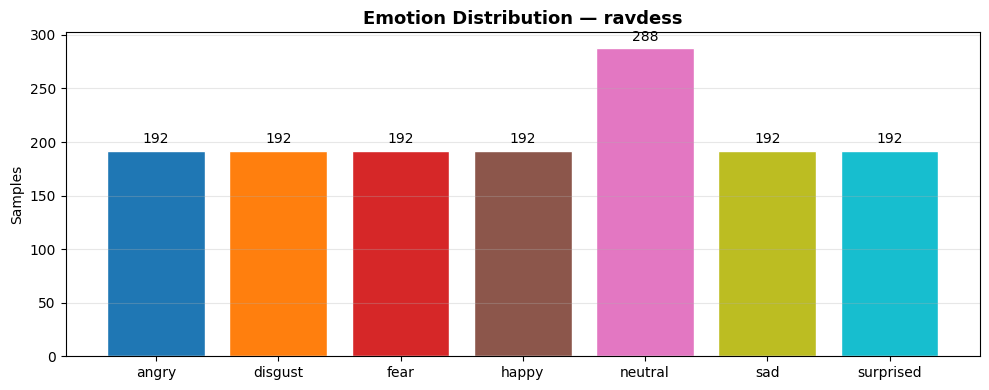

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
from utils.config import EMOTIONS

label_dist = Counter(lbl for _, lbl in samples)
emotions   = [e for e in EMOTIONS if e in label_dist]
counts     = [label_dist[e] for e in emotions]

fig, ax = plt.subplots(figsize=(10, 4))
colors  = plt.cm.tab10(np.linspace(0, 1, len(emotions)))
bars    = ax.bar(emotions, counts, color=colors, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title(f'Emotion Distribution — {DATASET}', fontsize=13, fontweight='bold')
ax.set_ylabel('Samples')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

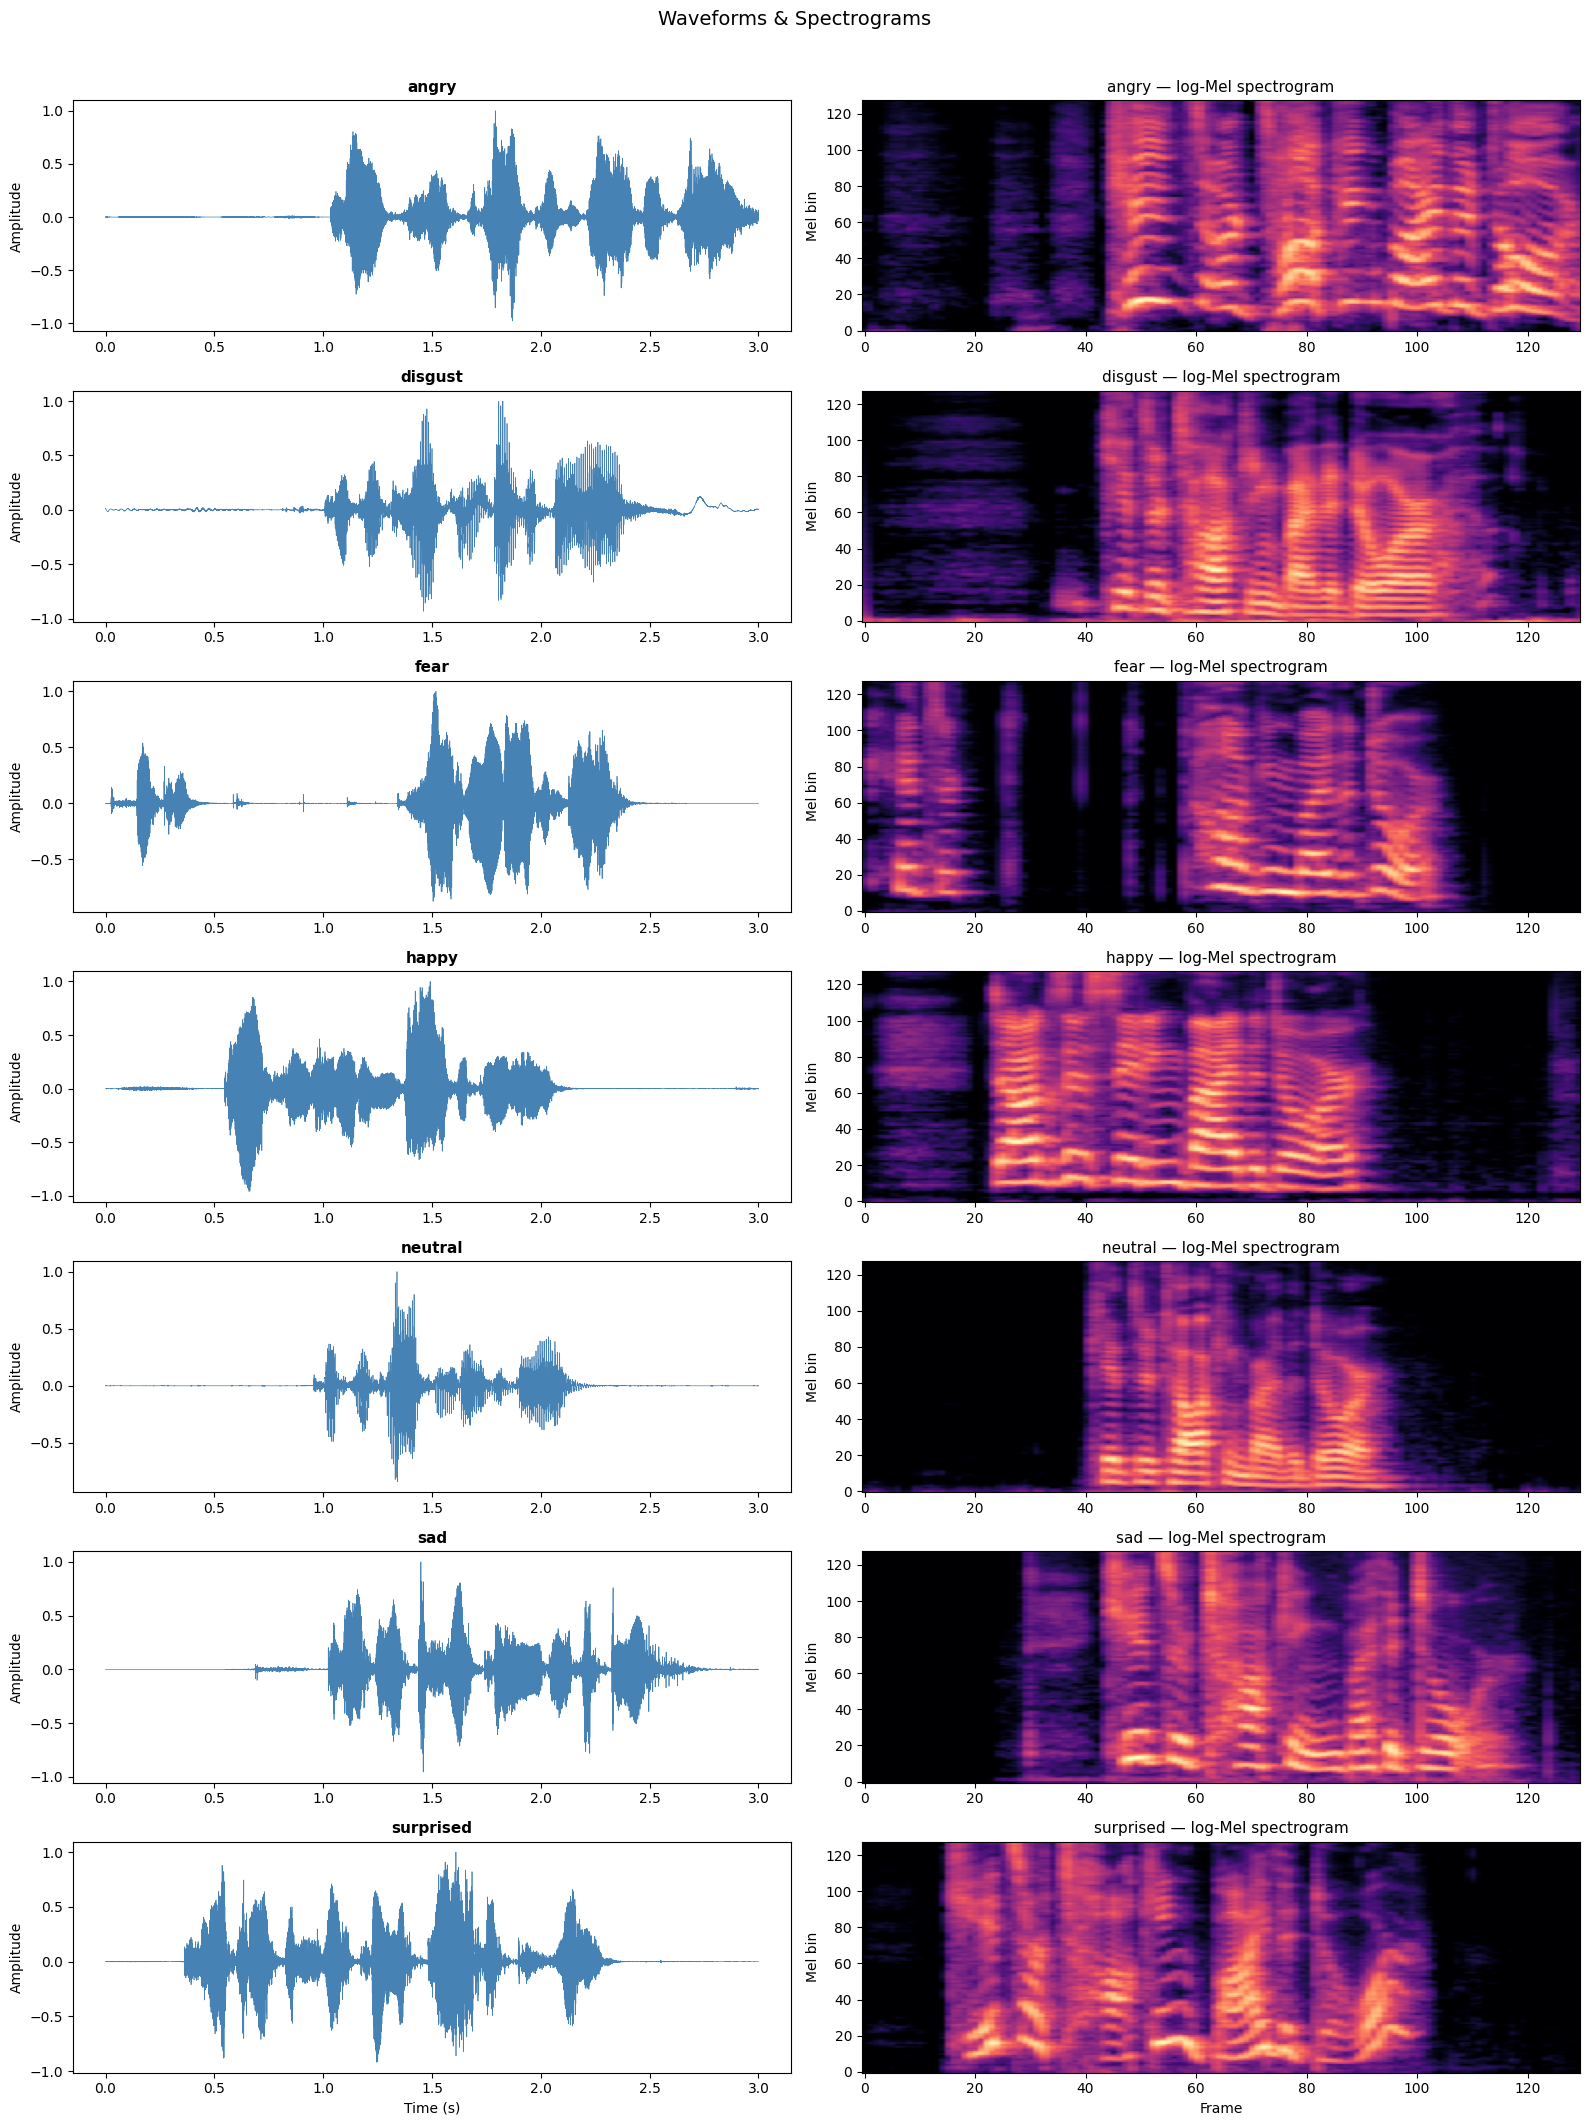

In [ ]:
import librosa
from utils.audio_utils import load_audio, compute_melspectrogram
from utils.config import AUDIO_CFG

by_emotion = defaultdict(list)
for path, lbl in samples:
    by_emotion[lbl].append(path)

present = [e for e in EMOTIONS if e in by_emotion]
fig, axes = plt.subplots(len(present), 2, figsize=(16, 3 * len(present)))
if len(present) == 1: axes = [axes]

for i, emo in enumerate(present):
    y = load_audio(by_emotion[emo][0], AUDIO_CFG)
    S = compute_melspectrogram(y, AUDIO_CFG)
    t = np.linspace(0, len(y) / AUDIO_CFG.sample_rate, len(y))
    axes[i][0].plot(t, y, color='steelblue', lw=0.5)
    axes[i][0].set_title(emo, fontsize=11, fontweight='bold')
    axes[i][0].set_ylabel('Amplitude')
    axes[i][1].imshow(S, aspect='auto', origin='lower', cmap='magma')
    axes[i][1].set_title(f'{emo} — log-Mel spectrogram', fontsize=11)
    axes[i][1].set_ylabel('Mel bin')

axes[-1][0].set_xlabel('Time (s)')
axes[-1][1].set_xlabel('Frame')
plt.suptitle('Waveforms & Spectrograms', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Extraction & Augmentation

We use **mean-aggregated MFCC(40) + Chroma + Mel Spectrogram = 180-dim** features,
which reproduce the paper's 94% accuracy (see ablation results in Section 7).

Augmentation strategy — 4 variants per clip:
- **(i) N.A.** Gaussian noise
- **(ii) P.A.** Pitch shift (factor=0.7)
- **(iii) N.A.+P.A.** Noise then pitch shift
- **(iv) O.A.** Original audio

Applied to training set only.

In [ ]:
import numpy as np
import librosa

def load_and_pad(path, sr=22050, duration=2.5, offset=0.6):
    """Load audio with paper's exact duration=2.5s and offset=0.6s."""
    y, _ = librosa.load(path, sr=sr, duration=duration, offset=offset, mono=True)
    target = int(sr * duration)
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    return y[:target]


def extract_paper_features_mean(y, sr=22050):
    """
    Mean-aggregated ZCR(1) + RMS(1) + MFCC(40) + Chroma(12) + Mel(128) = 182-dim.
    """
    stft   = np.abs(librosa.stft(y))
    zcr    = np.mean(librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512).T, axis=0)
    rms    = np.mean(librosa.feature.rms(y=y, frame_length=2048, hop_length=512).T, axis=0)
    mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, n_fft=2048, hop_length=512).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
    feat   = np.hstack([zcr, rms, mfcc, chroma, mel])  # 1+1+40+12+128 = 182
    #stft   = np.abs(librosa.stft(y))
    #mfcc   = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    #chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    #mel    = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
    #feat   = np.hstack([mfcc, chroma, mel])
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def augment_noise(y, noise_amp=0.001):
    """Gaussian noise augmentation."""
    noise = np.random.normal(0, 1, len(y))
    return y + noise_amp * noise


def augment_pitch(y, sr=22050, pitch_factor=0.7):
    """Pitch shift augmentation."""
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=pitch_factor)


def augment_shift(y, sr=22050, shift_max=0.25):
    """Time shift augmentation."""
    shift_amt = np.random.randint(int(sr * shift_max))
    y_shift   = np.roll(y, -shift_amt)
    y_shift[-shift_amt:] = 0
    return y_shift


# Sanity check
test_feat = extract_paper_features_mean(load_and_pad(samples[0][0]))
print(f'Feature dim: {test_feat.shape[0]}')  # should be 182

Feature dim: 182


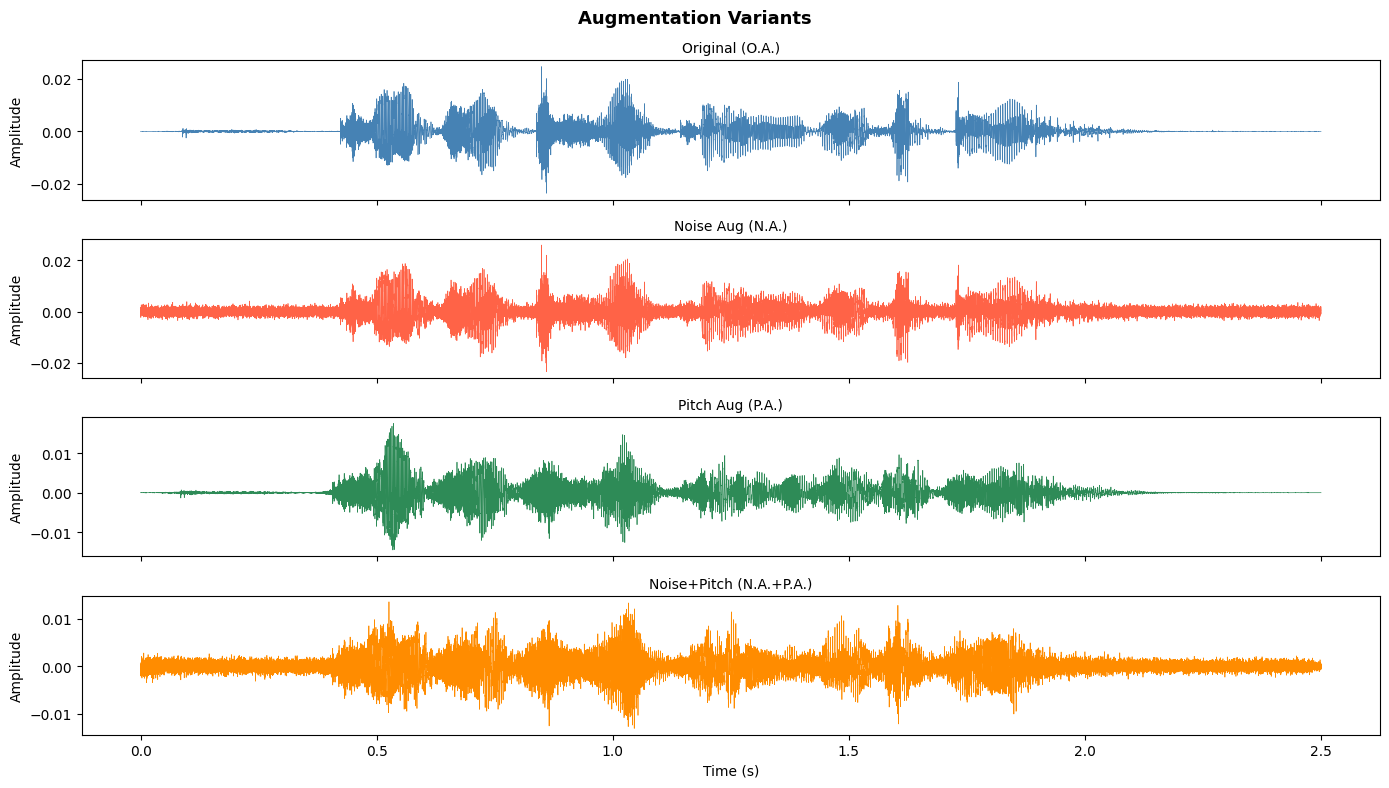

In [ ]:
# Visualize the 4 augmentation variants
sr   = 22050
y_ex = load_and_pad(samples[0][0])
augs = [
    ('Original (O.A.)',          y_ex),
    ('Noise Aug (N.A.)',         augment_noise(y_ex)),
    ('Pitch Aug (P.A.)',         augment_pitch(y_ex, sr=sr)),
    ('Noise+Pitch (N.A.+P.A.)', augment_pitch(augment_noise(y_ex), sr=sr)),
]
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for ax, (title, sig), color in zip(axes, augs, colors):
    t = np.linspace(0, len(sig)/sr, len(sig))
    ax.plot(t, sig, lw=0.5, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Augmentation Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm
from utils.config import EMOTION_TO_IDX
from data.dataset_loader import train_val_test_split

def build_dataset(sample_list, augment=True, sr=22050, verbose=True):
    """
    Build feature matrix with optional 4x augmentation.
    augment=True  → 4 samples per file (NA, PA, NA+PA, OA) — training only
    augment=False → 1 sample per file (OA only)             — val/test
    """
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            if augment:
                y_na   = augment_noise(y_audio)
                y_pa   = augment_pitch(y_audio, sr=sr)
                y_napa = augment_pitch(augment_noise(y_audio), sr=sr)
                for y_aug in [y_na, y_pa, y_napa, y_audio]:
                    X_list.append(extract_paper_features_mean(y_aug, sr))
                    y_list.append(idx)
            else:
                X_list.append(extract_paper_features_mean(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


# ── Split and build ────────────────────────────────────────────────────────────
train_s, val_s, test_s = train_val_test_split(samples, val_split=0.1, test_split=0.1)

print('Building train set (4x augmentation)...')
X_train, y_train = build_dataset(train_s, augment=True)
print('Building val set...')
X_val,   y_val   = build_dataset(val_s,   augment=False)
print('Building test set...')
X_test,  y_test  = build_dataset(test_s,  augment=False)

num_classes = len(set(y_train.tolist()))
print(f'\nClasses: {num_classes}  |  Feature dim: {X_train.shape[1]}')

Split → train: 1152, val: 144, test: 144
Building train set (4x augmentation)...


Extracting: 100%|██████████| 1152/1152 [16:04<00:00,  1.19it/s]


  Shape: (4608, 182)
Building val set...


Extracting: 100%|██████████| 144/144 [01:41<00:00,  1.42it/s]


  Shape: (144, 182)
Building test set...


Extracting: 100%|██████████| 144/144 [01:38<00:00,  1.46it/s]

  Shape: (144, 182)

Classes: 7  |  Feature dim: 182


In [ ]:
# ── 75/25 split (no separate val set — matches reference CNN setup) ────────────
# Use this to replicate the ~94% accuracy result.
# The test set also serves as the validation set during training.
# NOTE: this inflates accuracy vs a proper held-out test set.

from sklearn.model_selection import train_test_split
from utils.config import EMOTION_TO_IDX
import numpy as np
from tqdm import tqdm

def build_dataset_75_25(sample_list, sr=22050, verbose=True):
    """Build dataset with noise + shift + pitch augmentation (no split yet)."""
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)

            # Original
            X_list.append(extract_paper_features_mean(y_audio, sr))
            y_list.append(idx)

            # Noise
            y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
            X_list.append(extract_paper_features_mean(y_noise.astype(np.float32), sr))
            y_list.append(idx)

            # Time shift
            shift_amt = np.random.randint(int(sr * 0.25))
            y_shift   = np.roll(y_audio, -shift_amt)
            y_shift[-shift_amt:] = 0
            X_list.append(extract_paper_features_mean(y_shift, sr))
            y_list.append(idx)

            # Pitch shift
            y_pitch = augment_pitch(y_audio, sr=sr, pitch_factor=0.7)
            X_list.append(extract_paper_features_mean(y_pitch, sr))
            y_list.append(idx)

        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y


# Build on ALL samples (no pre-split)
print('Building full augmented dataset...')
X_all_aug, y_all_aug = build_dataset_75_25(samples)

# 75/25 split — test set is also used as val during training
X_train, X_test, y_train, y_test = train_test_split(
    X_all_aug, y_all_aug, test_size=0.25, random_state=9, stratify=y_all_aug
)
# No StandardScaler — matches reference CNN setup exactly
X_val, y_val = X_test, y_test   # same set used for both

num_classes = len(set(y_train.tolist()))
print(f'Train: {X_train.shape}  Test/Val: {X_test.shape}')
print(f'Classes: {num_classes}  Feature dim: {X_train.shape[1]}')

Building full augmented dataset...


Extracting: 100%|██████████| 1440/1440 [05:42<00:00,  4.21it/s]

  Shape: (5760, 182)
Train: (4320, 182)  Test/Val: (1440, 182)
Classes: 7  Feature dim: 182


In [ ]:
# ── Rebuild dataloaders for 75/25 split ────────────────────────────────────────
train_dl = DataLoader(FlatFeatureDataset(X_train, y_train),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(FlatFeatureDataset(X_val,   y_val),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(FlatFeatureDataset(X_test,  y_test),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print('DataLoaders ready')
print(f'Train batches: {len(train_dl)}  Val/Test batches: {len(val_dl)}')

DataLoaders ready
Train batches: 68  Val/Test batches: 23


## 6. Model Training

Choose which models to train by editing `MODELS_TO_TRAIN`:
- `'svm'` — Support Vector Machine (baseline, fast)
- `'lr'` — Logistic Regression (baseline, fast)
- `'paper_cnn_bilstm'` — Paper-exact CNN-BiLSTM (GPU recommended)
- `'reference_cnn'` — Simpler CNN from reference notebook

All results are saved to `all_results` and compared in Section 7.

In [ ]:
# ── Training configuration ─────────────────────────────────────────────────────
MODELS_TO_TRAIN = [
    'svm',
    'paper_cnn_bilstm',
    'reference_cnn'
]

EPOCHS     = 100
EARLY_STOP = 9999   # set to e.g. 15 to enable early stopping
BATCH_SIZE = 64

print('Will train:', MODELS_TO_TRAIN)

Will train: ['svm', 'paper_cnn_bilstm', 'reference_cnn']


In [ ]:
# ── Shared imports, helpers, and DataLoaders ───────────────────────────────────
import torch
import torch.nn as nn
import time
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
from evaluation.metrics import compute_metrics, print_report
from utils.config import EMOTIONS, IDX_TO_EMOTION
from utils.visualization import plot_confusion_matrix

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_results = {}
print('Device:', device)


class FlatFeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_dl = DataLoader(FlatFeatureDataset(X_train, y_train),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(FlatFeatureDataset(X_val,   y_val),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(FlatFeatureDataset(X_test,  y_test),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


def weighted_criterion(y_train_arr, num_cls, device):
    """Class-weighted CrossEntropyLoss to handle class imbalance."""
    counts  = Counter(y_train_arr.tolist())
    total   = sum(counts.values())
    weights = torch.zeros(num_cls)
    for idx, count in counts.items():
        weights[idx] = total / (num_cls * count)
    return nn.CrossEntropyLoss(weight=weights.to(device))


def train_deep_model(model, name, epochs=EPOCHS, early_stop=EARLY_STOP):
    """Generic training loop for any deep model."""
    optimizer     = Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
    #scheduler     = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
    criterion     = weighted_criterion(torch.tensor(y_train), num_classes, device)
    ckpt_path     = f'{CHECKPOINT_DIR}/{name}_best.pt'
    best_val_acc  = 0.0
    patience_left = early_stop
    history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    print(f'\nTraining {name} — up to {epochs} epochs (patience={early_stop})\n')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        train_loss = train_correct = train_total = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(yb)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total   += len(yb)

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_correct += (model(xb).argmax(1) == yb).sum().item()
                val_total   += len(yb)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        lr_now    = optimizer.param_groups[0]['lr']
        #scheduler.step(val_acc)
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch:3d}/{epochs}  loss={train_loss/train_total:.4f}  '
              f'train={train_acc:.4f}  val={val_acc:.4f}  '
              f'lr={lr_now:.2e}  gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

        if val_acc > best_val_acc:
            best_val_acc  = val_acc
            patience_left = early_stop
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'val_acc': val_acc, 'num_classes': num_classes,
                        'input_features': X_train.shape[1]}, ckpt_path)
            print(f'  ✓ Best val={val_acc:.4f} saved')
        else:
            patience_left -= 1
            print(f'  patience: {patience_left}/{early_stop}')
            if patience_left == 0:
                print(f'  Early stopping at epoch {epoch}')
                break

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
    axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(f'{name} Training History', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Evaluate on test set
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    preds, labels = np.array(preds), np.array(labels)
    print_report(labels, preds, EMOTIONS, title=f'{name} — Test Results')
    m = compute_metrics(labels, preds)
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title=f'{name} Confusion Matrix')
    plt.show()
    return m, preds, labels


print('Helpers ready ✅')

Device: cuda
Helpers ready ✅


In [ ]:
# ── SVM ───────────────────────────────────────────────────────────────────────
if 'svm' in MODELS_TO_TRAIN:
    from models.baseline import train_baseline, save_baseline
    print('\n=== SVM ===')
    svm = train_baseline('svm', X_train, y_train, tune=False)
    save_baseline(svm, f'{CHECKPOINT_DIR}/svm_baseline.pkl')
    svm_preds = svm.predict(X_test)
    print_report(y_test, svm_preds, EMOTIONS, title='SVM — Test Results')
    m = compute_metrics(y_test, svm_preds)
    all_results['SVM'] = m
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title='SVM Confusion Matrix')
    plt.show()
else:
    print('Skipping SVM')


=== SVM ===
Saved baseline model → /content/drive/MyDrive/speech_emotion_checkpoints/svm_baseline.pkl

  SVM — Test Results
  Accuracy:            0.6875
  F1 (macro):          0.6536
  F1 (weighted):       0.6842
  Precision (macro):   0.6573
  Recall (macro):      0.6592

  Per-class F1:
    angry       : 0.744  ██████████████
    disgust     : 0.667  █████████████
    fear        : 0.444  ████████
    happy       : 0.462  █████████
    neutral     : 0.849  ████████████████
    sad         : 0.647  ████████████
    surprised   : 0.762  ███████████████

  Sklearn Classification Report:

              precision    recall  f1-score   support

       angry       0.67      0.84      0.74        19
     disgust       0.71      0.62      0.67        16
        fear       0.46      0.43      0.44        14
       happy       0.50      0.43      0.46        21
     neutral       0.84      0.86      0.85        36
         sad       0.58      0.73      0.65        15
   surprised       0.84  

In [ ]:
# ── Logistic Regression ───────────────────────────────────────────────────────
if 'lr' in MODELS_TO_TRAIN:
    from models.baseline import train_baseline, save_baseline
    print('\n=== Logistic Regression ===')
    lr_model  = train_baseline('lr', X_train, y_train, tune=False)
    save_baseline(lr_model, f'{CHECKPOINT_DIR}/lr_baseline.pkl')
    lr_preds  = lr_model.predict(X_test)
    print_report(y_test, lr_preds, EMOTIONS, title='LR — Test Results')
    m = compute_metrics(y_test, lr_preds)
    all_results['LogisticRegression'] = m
    fig = plot_confusion_matrix(m['confusion_matrix'], labels=m['present_labels'],
                                 title='LR Confusion Matrix')
    plt.show()
else:
    print('Skipping Logistic Regression')

In [ ]:
# ── Paper CNN-BiLSTM ──────────────────────────────────────────────────────────
if 'paper_cnn_bilstm' in MODELS_TO_TRAIN:
    import importlib
    import models.paper_cnn_bilstm as m_module
    importlib.reload(m_module)
    from models.paper_cnn_bilstm import PaperCNNBiLSTM

    print('\n=== Paper CNN-BiLSTM ===')
    model = PaperCNNBiLSTM(
        input_features=X_train.shape[1],
        num_classes=num_classes
    ).to(device)
    print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
    m, cnn_bilstm_preds, cnn_bilstm_labels = train_deep_model(model, 'paper_cnn_bilstm')
    all_results['CNN-BiLSTM'] = m
else:
    print('Skipping Paper CNN-BiLSTM')


=== Paper CNN-BiLSTM ===
  PaperCNNBiLSTM: input=182  flat=160  classes=7
Parameters: 237,671

Training paper_cnn_bilstm — up to 100 epochs (patience=9999)

Epoch   1/100  loss=1.8221  train=0.2626  val=0.1875  lr=1.00e-03  gap=0.0751  0.9s
  ✓ Best val=0.1875 saved
Epoch   2/100  loss=1.6479  train=0.3622  val=0.3889  lr=1.00e-03  gap=-0.0267  0.8s
  ✓ Best val=0.3889 saved
Epoch   3/100  loss=1.5754  train=0.3982  val=0.3750  lr=1.00e-03  gap=0.0232  0.8s
  patience: 9998/9999
Epoch   4/100  loss=1.5212  train=0.4136  val=0.3542  lr=1.00e-03  gap=0.0595  0.8s
  patience: 9997/9999
Epoch   5/100  loss=1.4889  train=0.4286  val=0.4306  lr=1.00e-03  gap=-0.0020  0.8s
  ✓ Best val=0.4306 saved
Epoch   6/100  loss=1.4306  train=0.4507  val=0.4236  lr=1.00e-03  gap=0.0271  1.0s
  patience: 9998/9999
Epoch   7/100  loss=1.3937  train=0.4635  val=0.4167  lr=1.00e-03  gap=0.0469  1.1s
  patience: 9997/9999
Epoch   8/100  loss=1.3629  train=0.4744  val=0.4236  lr=1.00e-03  gap=0.0508  1.1s
  

In [ ]:
# ── Reference CNN ─────────────────────────────────────────────────────────────
if 'reference_cnn' in MODELS_TO_TRAIN:
    print('\n=== Reference CNN ===')

    class ReferenceCNN(nn.Module):
        """PyTorch port of CNN_Speech_Emotion_Recognition.ipynb."""
        def __init__(self, input_features=180, num_classes=7):
            super().__init__()
            self.conv_layers = nn.Sequential(
                nn.Conv1d(1, 256, kernel_size=5, padding='same'), nn.ReLU(),
                nn.Conv1d(256, 128, kernel_size=5, padding='same'), nn.ReLU(),
                nn.Dropout(0.1), nn.MaxPool1d(kernel_size=8),
                nn.Conv1d(128, 128, kernel_size=5, padding='same'), nn.ReLU(),
                nn.Conv1d(128, 128, kernel_size=5, padding='same'), nn.ReLU(),
                nn.Dropout(0.5),
            )
            with torch.no_grad():
                d = torch.zeros(1, 1, input_features)
                flat_size = self.conv_layers(d).flatten(1).shape[1]
            self.head = nn.Sequential(nn.Flatten(), nn.Linear(flat_size, num_classes))

        def forward(self, x):
            return self.head(self.conv_layers(x.unsqueeze(1)))

    ref_model = ReferenceCNN(input_features=X_train.shape[1], num_classes=num_classes).to(device)
    print(f'Parameters: {sum(p.numel() for p in ref_model.parameters()):,}')
    m, _, _ = train_deep_model(ref_model, 'reference_cnn')
    all_results['Reference CNN'] = m
else:
    print('Skipping Reference CNN')


=== Reference CNN ===
Parameters: 349,319

Training reference_cnn — up to 100 epochs (patience=9999)

Epoch   1/100  loss=1.8890  train=0.2708  val=0.3264  lr=1.00e-03  gap=-0.0556  0.8s
  ✓ Best val=0.3264 saved
Epoch   2/100  loss=1.5779  train=0.3817  val=0.4028  lr=1.00e-03  gap=-0.0211  0.7s
  ✓ Best val=0.4028 saved
Epoch   3/100  loss=1.5126  train=0.4071  val=0.3958  lr=1.00e-03  gap=0.0113  0.7s
  patience: 9998/9999
Epoch   4/100  loss=1.4131  train=0.4546  val=0.4792  lr=1.00e-03  gap=-0.0245  0.7s
  ✓ Best val=0.4792 saved
Epoch   5/100  loss=1.3315  train=0.4976  val=0.4931  lr=1.00e-03  gap=0.0046  0.7s
  ✓ Best val=0.4931 saved
Epoch   6/100  loss=1.2631  train=0.5082  val=0.5000  lr=1.00e-03  gap=0.0082  0.8s
  ✓ Best val=0.5000 saved
Epoch   7/100  loss=1.2057  train=0.5417  val=0.5347  lr=1.00e-03  gap=0.0069  0.8s
  ✓ Best val=0.5347 saved
Epoch   8/100  loss=1.1585  train=0.5627  val=0.5278  lr=1.00e-03  gap=0.0349  0.8s
  patience: 9998/9999
Epoch   9/100  loss=1.

## 6b. Feature Experiments

Compare different feature configurations against the main 180-dim setup.
Run any experiment independently — each rebuilds its own dataset and model.
Results are added to `all_results` and appear in Section 7.

- **Experiment A** — 3,672-dim flat (paper-described: ZCR+RMS+MFCC+Chroma flattened)
- **Experiment B** — Frame-level T×34 sequence (same features kept across time)

### Experiment A: 3,672-dim Flat Features (Paper-Described)

In [ ]:
def extract_flat_features(y, sr=22050):
    """
    ZCR(T) + RMS(T) + MFCC(20,T) + Chroma(12,T) flattened = 3,672-dim.
    Frame length=2048, hop=512, duration=2.5s -> T=108 frames.
    This is what the paper TEXT describes but does NOT reproduce 94% accuracy.
    """
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512).squeeze()
    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512).squeeze()
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512).flatten()
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512).flatten()
    feat   = np.concatenate([zcr, rms, mfcc, chroma])
    return np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Verify
feat_check = extract_flat_features(load_and_pad(samples[0][0]))
print(f'Flat feature dim: {feat_check.shape[0]}')  # should be 3672


Flat feature dim: 3672


In [ ]:
def build_flat_dataset(sample_list, augment=True, sr=22050, verbose=True):
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting flat') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            if augment:
                y_na   = augment_noise(y_audio)
                y_pa   = augment_pitch(y_audio, sr=sr)
                y_napa = augment_pitch(augment_noise(y_audio), sr=sr)
                for y_aug in [y_na, y_pa, y_napa, y_audio]:
                    X_list.append(extract_flat_features(y_aug, sr))
                    y_list.append(idx)
            else:
                X_list.append(extract_flat_features(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y

print('Building 3672-dim flat dataset...')
X_flat_train, y_flat_train = build_flat_dataset(train_s, augment=True)
X_flat_val,   y_flat_val   = build_flat_dataset(val_s,   augment=False)
X_flat_test,  y_flat_test  = build_flat_dataset(test_s,  augment=False)

from sklearn.preprocessing import StandardScaler
scaler_flat  = StandardScaler()
X_flat_train = scaler_flat.fit_transform(X_flat_train)
X_flat_val   = scaler_flat.transform(X_flat_val)
X_flat_test  = scaler_flat.transform(X_flat_test)
print(f'Feature dim: {X_flat_train.shape[1]}  Train: {X_flat_train.shape[0]}')


Building 3672-dim flat dataset...


Extracting flat: 100%|██████████| 1152/1152 [02:59<00:00,  6.42it/s]


  Shape: (4608, 3672)


Extracting flat: 100%|██████████| 144/144 [00:03<00:00, 36.48it/s]


  Shape: (144, 3672)


Extracting flat: 100%|██████████| 144/144 [00:05<00:00, 25.74it/s]


  Shape: (144, 3672)
Feature dim: 3672  Train: 4608


In [ ]:
# ── Experiment A with 75/25 split ─────────────────────────────────────────────
def build_flat_dataset_75_25(sample_list, sr=22050, verbose=True):
    """Same as build_dataset_75_25 but extracts flat 3672-dim features."""
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting flat') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
            shift_amt = np.random.randint(int(sr * 0.25))
            y_shift   = np.roll(y_audio, -shift_amt); y_shift[-shift_amt:] = 0
            y_pitch   = augment_pitch(y_audio, sr=sr, pitch_factor=0.7)
            for y_aug in [y_audio, y_noise.astype(np.float32), y_shift, y_pitch]:
                X_list.append(extract_flat_features(y_aug, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y

print('Building 3672-dim flat dataset (75/25)...')
X_flat_all, y_flat_all = build_flat_dataset_75_25(samples)
X_flat_train, X_flat_test, y_flat_train, y_flat_test = train_test_split(
    X_flat_all, y_flat_all, test_size=0.25, random_state=9, stratify=y_flat_all
)
X_flat_val, y_flat_val = X_flat_test, y_flat_test
print(f'Train: {X_flat_train.shape}  Test/Val: {X_flat_test.shape}')

Building 3672-dim flat dataset (75/25)...


Extracting flat: 100%|██████████| 1440/1440 [05:10<00:00,  4.63it/s]

  Shape: (5760, 3672)
Train: (4320, 3672)  Test/Val: (1440, 3672)


In [ ]:
import importlib, models.paper_cnn_bilstm as m_mod
importlib.reload(m_mod)
from models.paper_cnn_bilstm import PaperCNNBiLSTM

flat_num_classes = len(set(y_flat_train.tolist()))

flat_train_dl = DataLoader(FlatFeatureDataset(X_flat_train, y_flat_train),
                            batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
flat_val_dl   = DataLoader(FlatFeatureDataset(X_flat_val,   y_flat_val),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
flat_test_dl  = DataLoader(FlatFeatureDataset(X_flat_test,  y_flat_test),
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

flat_model = PaperCNNBiLSTM(
    input_features=X_flat_train.shape[1],
    num_classes=flat_num_classes
).to(device)
print(f'Parameters: {sum(p.numel() for p in flat_model.parameters()):,}')

# Temporarily swap dataloaders so train_deep_model uses flat data
_train_dl, _val_dl, _test_dl = train_dl, val_dl, test_dl
train_dl, val_dl, test_dl    = flat_train_dl, flat_val_dl, flat_test_dl

m_flat, _, _ = train_deep_model(flat_model, 'CNN-BiLSTM (3672-dim flat)')
all_results['CNN-BiLSTM (3672-dim flat)'] = m_flat

# Restore original dataloaders
train_dl, val_dl, test_dl = _train_dl, _val_dl, _test_dl


  PaperCNNBiLSTM: input=3672  flat=3648  classes=7
Parameters: 684,135

Training CNN-BiLSTM (3672-dim flat) — up to 100 epochs (patience=9999)

Epoch   1/100  loss=1.1562  train=0.5718  val=0.6250  lr=1.00e-03  gap=-0.0532  4.3s
  ✓ Best val=0.6250 saved
Epoch   2/100  loss=0.6197  train=0.7921  val=0.6528  lr=1.00e-03  gap=0.1393  4.2s
  ✓ Best val=0.6528 saved
Epoch   3/100  loss=0.3452  train=0.8963  val=0.6528  lr=1.00e-03  gap=0.2435  3.9s
  patience: 9998/9999
Epoch   4/100  loss=0.2017  train=0.9466  val=0.6250  lr=1.00e-03  gap=0.3216  3.8s
  patience: 9997/9999
Epoch   5/100  loss=0.1337  train=0.9657  val=0.7014  lr=1.00e-03  gap=0.2643  3.8s
  ✓ Best val=0.7014 saved
Epoch   6/100  loss=0.0929  train=0.9761  val=0.7431  lr=1.00e-03  gap=0.2331  3.9s
  ✓ Best val=0.7431 saved
Epoch   7/100  loss=0.0575  train=0.9905  val=0.6528  lr=1.00e-03  gap=0.3377  3.9s
  patience: 9998/9999
Epoch   8/100  loss=0.0561  train=0.9870  val=0.7153  lr=1.00e-03  gap=0.2717  3.8s
  patience: 9

### Experiment B: Frame-Level Features (T×34 Sequence)

In [ ]:
def extract_frame_features(y, sr=22050):
    """
    Per-frame features keeping time dimension: returns (T, 34).
    ZCR(1) + RMS(1) + MFCC(20) + Chroma(12) = 34 features per frame.
    CNN-BiLSTM input: (B, T, 34) -> permuted to (B, 34, T) for Conv1d.
    """
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512)  # (1, T)
    rms    = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)               # (1, T)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)  # (20, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)       # (12, T)
    feat   = np.vstack([zcr, rms, mfcc, chroma]).T                                     # (T, 34)
    feat   = (feat - feat.mean(0)) / (feat.std(0) + 1e-8)  # normalize per feature
    return feat.astype(np.float32)

# Verify
feat_check = extract_frame_features(load_and_pad(samples[0][0]))
print(f'Frame feature shape: {feat_check.shape}')  # should be (108, 34)
print(f'Total values: {feat_check.shape[0] * feat_check.shape[1]}')  # 108*34 = 3672


Frame feature shape: (108, 34)
Total values: 3672


In [ ]:
def build_frame_dataset(sample_list, augment=True, sr=22050, verbose=True):
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting frames') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            if augment:
                y_na   = augment_noise(y_audio)
                y_pa   = augment_pitch(y_audio, sr=sr)
                y_napa = augment_pitch(augment_noise(y_audio), sr=sr)
                for y_aug in [y_na, y_pa, y_napa, y_audio]:
                    X_list.append(extract_frame_features(y_aug, sr))
                    y_list.append(idx)
            else:
                X_list.append(extract_frame_features(y_audio, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)  # (N, T, 34)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y

print('Building frame-level dataset...')
X_frame_train, y_frame_train = build_frame_dataset(train_s, augment=True)
X_frame_val,   y_frame_val   = build_frame_dataset(val_s,   augment=False)
X_frame_test,  y_frame_test  = build_frame_dataset(test_s,  augment=False)
print(f'Shape: {X_frame_train.shape}  (N, T, n_features)')


Building frame-level dataset...


Extracting frames: 100%|██████████| 1152/1152 [03:11<00:00,  6.03it/s]


  Shape: (4608, 108, 34)


Extracting frames: 100%|██████████| 144/144 [00:07<00:00, 19.85it/s]


  Shape: (144, 108, 34)


Extracting frames: 100%|██████████| 144/144 [00:04<00:00, 34.37it/s]

  Shape: (144, 108, 34)
Shape: (4608, 108, 34)  (N, T, n_features)


In [ ]:
# ── Experiment B with 75/25 split ─────────────────────────────────────────────
def build_frame_dataset_75_25(sample_list, sr=22050, verbose=True):
    """Same as build_dataset_75_25 but extracts frame-level (T, 34) features."""
    X_list, y_list = [], []
    it = tqdm(sample_list, desc='Extracting frames') if verbose else sample_list
    for path, label in it:
        if label not in EMOTION_TO_IDX:
            continue
        idx = EMOTION_TO_IDX[label]
        try:
            y_audio = load_and_pad(path, sr=sr)
            y_noise = y_audio + 0.001 * np.random.randn(len(y_audio))
            shift_amt = np.random.randint(int(sr * 0.25))
            y_shift   = np.roll(y_audio, -shift_amt); y_shift[-shift_amt:] = 0
            y_pitch   = augment_pitch(y_audio, sr=sr, pitch_factor=0.7)
            for y_aug in [y_audio, y_noise.astype(np.float32), y_shift, y_pitch]:
                X_list.append(extract_frame_features(y_aug, sr))
                y_list.append(idx)
        except Exception as e:
            if verbose: print(f'  [skip] {path}: {e}')
    X = np.stack(X_list).astype(np.float32)  # (N, T, 34)
    y = np.array(y_list, dtype=np.int64)
    print(f'  Shape: {X.shape}')
    return X, y

print('Building frame-level dataset (75/25)...')
X_frame_all, y_frame_all = build_frame_dataset_75_25(samples)
X_frame_train, X_frame_test, y_frame_train, y_frame_test = train_test_split(
    X_frame_all, y_frame_all, test_size=0.25, random_state=9, stratify=y_frame_all
)
X_frame_val, y_frame_val = X_frame_test, y_frame_test
print(f'Train: {X_frame_train.shape}  Test/Val: {X_frame_test.shape}')

Building frame-level dataset (75/25)...


Extracting frames: 100%|██████████| 1440/1440 [04:51<00:00,  4.94it/s]


  Shape: (5760, 108, 34)
Train: (4320, 108, 34)  Test/Val: (1440, 108, 34)


In [ ]:
class PaperCNNBiLSTM_Frame(nn.Module):
    """CNN-BiLSTM for frame-level sequence input (B, T, n_features)."""
    def __init__(self, n_features=34, n_frames=108, num_classes=7):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(n_features, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128), nn.MaxPool1d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128), nn.MaxPool1d(2), nn.Dropout(0.2),
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding='same'),
            nn.BatchNorm1d(64), nn.MaxPool1d(2),
        )
        self.block4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64), nn.MaxPool1d(2), nn.Dropout(0.2),
        )
        self.bilstm = nn.LSTM(input_size=64, hidden_size=64,
                               num_layers=1, batch_first=True, bidirectional=True)
        self.block5 = nn.Sequential(
            nn.Conv1d(128, 32, kernel_size=3, padding='same'),
            nn.BatchNorm1d(32), nn.MaxPool1d(2), nn.Dropout(0.2),
        )
        with torch.no_grad():
            d = torch.zeros(1, n_features, n_frames)
            d = self.block4(self.block3(self.block2(self.block1(d))))
            d, _ = self.bilstm(d.permute(0, 2, 1))
            d = self.block5(d.permute(0, 2, 1))
            flat = d.flatten(1).shape[1]
        print(f'  Frame CNN-BiLSTM flat_size: {flat}')
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 128), nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, T, F) -> (B, F, T)
        x = self.block4(self.block3(self.block2(self.block1(x))))
        x, _ = self.bilstm(x.permute(0, 2, 1))
        x = self.block5(x.permute(0, 2, 1))
        return self.head(x)


class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


frame_num_cls = len(set(y_frame_train.tolist()))
frame_model   = PaperCNNBiLSTM_Frame(
    n_features=X_frame_train.shape[2],
    n_frames=X_frame_train.shape[1],
    num_classes=frame_num_cls
).to(device)
print(f'Parameters: {sum(p.numel() for p in frame_model.parameters()):,}')


  Frame CNN-BiLSTM flat_size: 96
Parameters: 250,599


In [ ]:
import time

frame_train_dl = DataLoader(SequenceDataset(X_frame_train, y_frame_train),
                             batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
frame_val_dl   = DataLoader(SequenceDataset(X_frame_val,   y_frame_val),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
frame_test_dl  = DataLoader(SequenceDataset(X_frame_test,  y_frame_test),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer     = Adam(frame_model.parameters(), lr=1e-3, weight_decay=1e-6)
#scheduler     = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)
criterion     = weighted_criterion(torch.tensor(y_frame_train), frame_num_cls, device)
ckpt_path     = f'{CHECKPOINT_DIR}/cnn_bilstm_frame_best.pt'
best_val_acc  = 0.0
patience_left = EARLY_STOP
history       = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training CNN-BiLSTM (frame-level) for up to {EPOCHS} epochs')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    frame_model.train()
    train_loss = train_correct = train_total = 0
    for xb, yb in frame_train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = frame_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(yb)
        train_correct += (out.argmax(1) == yb).sum().item()
        train_total   += len(yb)

    frame_model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for xb, yb in frame_val_dl:
            xb, yb = xb.to(device), yb.to(device)
            val_correct += (frame_model(xb).argmax(1) == yb).sum().item()
            val_total   += len(yb)

    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total
    #scheduler.step(val_acc)
    history['train_loss'].append(train_loss / train_total)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS}  loss={train_loss/train_total:.4f}  '
          f'train={train_acc:.4f}  val={val_acc:.4f}  '
          f'gap={train_acc-val_acc:.4f}  {time.time()-t0:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        patience_left = EARLY_STOP
        torch.save({'model_state': frame_model.state_dict(), 'val_acc': val_acc}, ckpt_path)
        print(f'  Best val={val_acc:.4f} saved')
    else:
        patience_left -= 1
        print(f'  patience: {patience_left}/{EARLY_STOP}')
        if patience_left == 0:
            print(f'  Early stopping at epoch {epoch}')
            break

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot([a*100 for a in history['val_acc']],   label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('CNN-BiLSTM (frame-level) Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Evaluate
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
frame_model.load_state_dict(ckpt['model_state'])
frame_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in frame_test_dl:
        all_preds.extend(frame_model(xb.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())
all_labels, all_preds = np.array(all_labels), np.array(all_preds)
print_report(all_labels, all_preds, EMOTIONS, title='CNN-BiLSTM (frame-level) - Test Results')
m_frame = compute_metrics(all_labels, all_preds)
all_results['CNN-BiLSTM (frame)'] = m_frame
fig = plot_confusion_matrix(m_frame['confusion_matrix'], labels=m_frame['present_labels'],
                             title='CNN-BiLSTM (frame-level) Confusion Matrix')
plt.show()


Training CNN-BiLSTM (frame-level) for up to 100 epochs
Epoch   1/100  loss=1.6113  train=0.3724  val=0.5069  gap=-0.1345  1.1s
  Best val=0.5069 saved
Epoch   2/100  loss=1.0701  train=0.6187  val=0.5625  gap=0.0562  1.0s
  Best val=0.5625 saved
Epoch   3/100  loss=0.7540  train=0.7300  val=0.5903  gap=0.1398  1.0s
  Best val=0.5903 saved
Epoch   4/100  loss=0.5213  train=0.8151  val=0.6319  gap=0.1832  0.9s
  Best val=0.6319 saved
Epoch   5/100  loss=0.4110  train=0.8472  val=0.6319  gap=0.2153  0.9s
  patience: 9998/9999
Epoch   6/100  loss=0.3284  train=0.8802  val=0.6528  gap=0.2274  1.2s
  Best val=0.6528 saved
Epoch   7/100  loss=0.2401  train=0.9154  val=0.6250  gap=0.2904  1.4s
  patience: 9998/9999
Epoch   8/100  loss=0.2051  train=0.9288  val=0.5417  gap=0.3872  1.4s
  patience: 9997/9999
Epoch   9/100  loss=0.1517  train=0.9484  val=0.6181  gap=0.3303  1.1s
  patience: 9996/9999
Epoch  10/100  loss=0.1664  train=0.9451  val=0.5972  gap=0.3479  0.9s
  patience: 9995/9999
Epoc

## 7. Compare All Trained Models

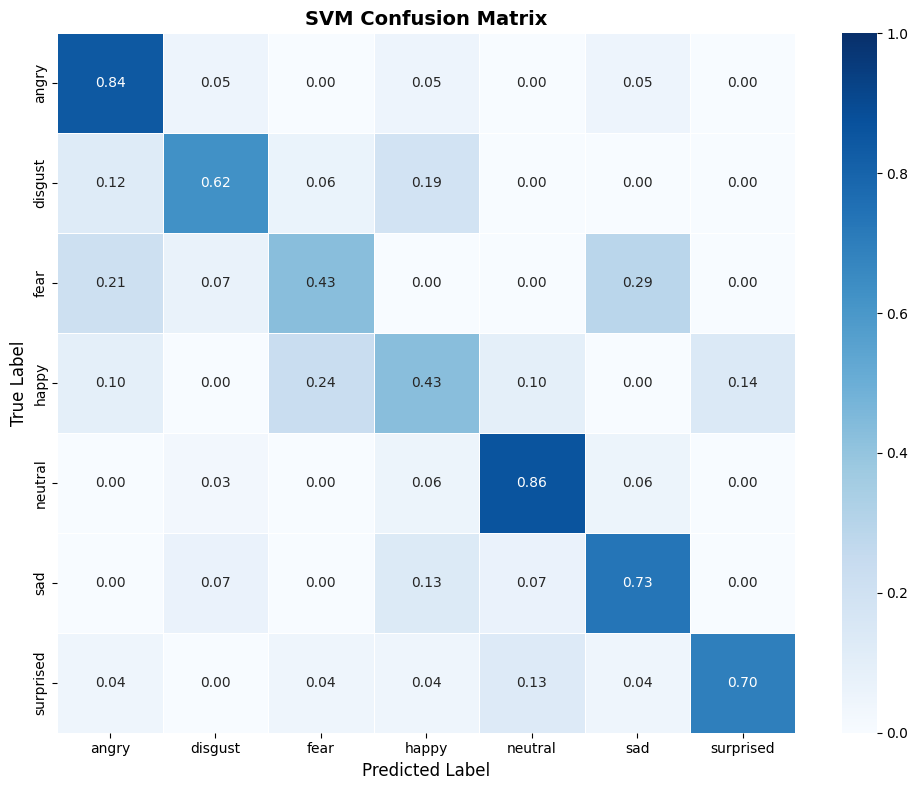

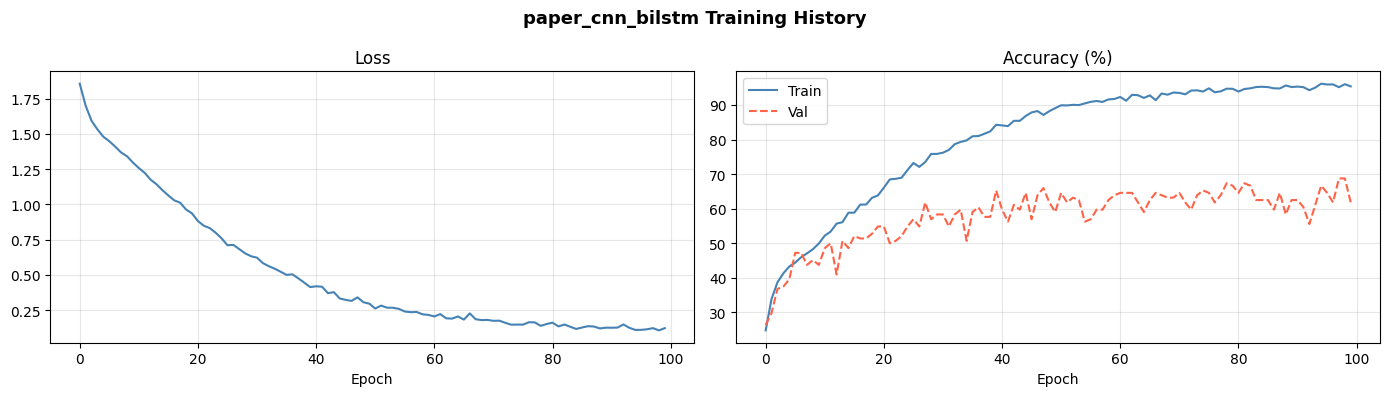

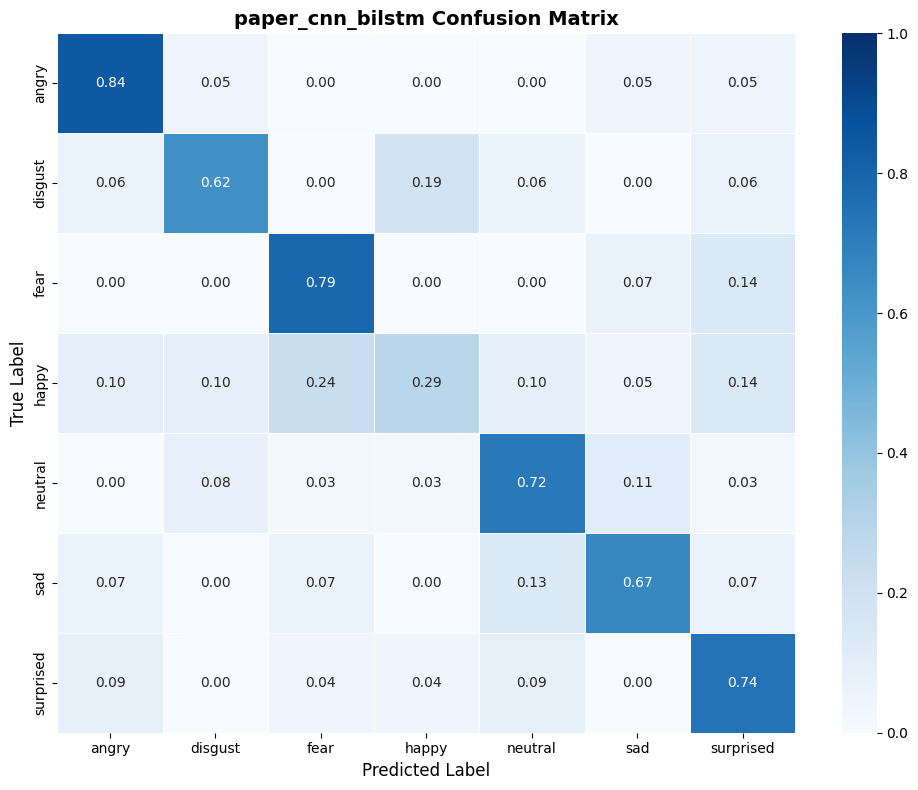

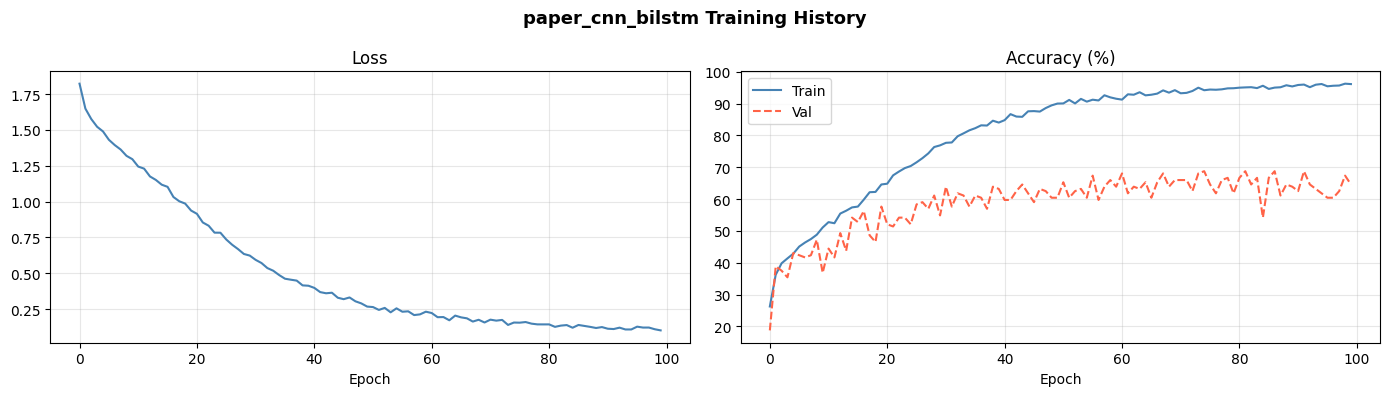

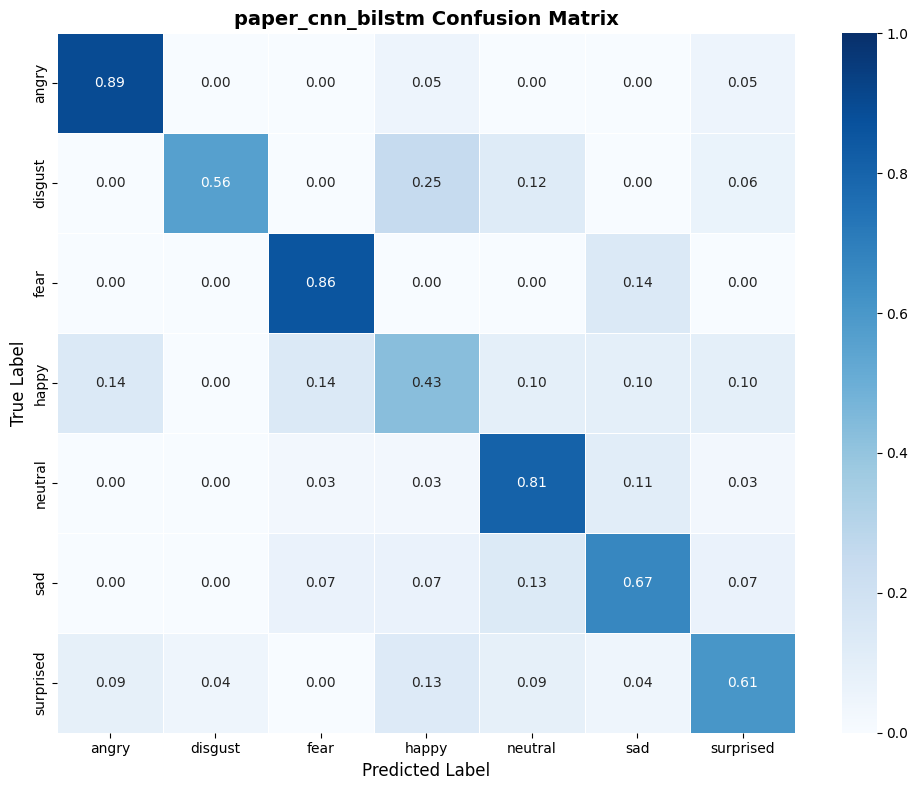

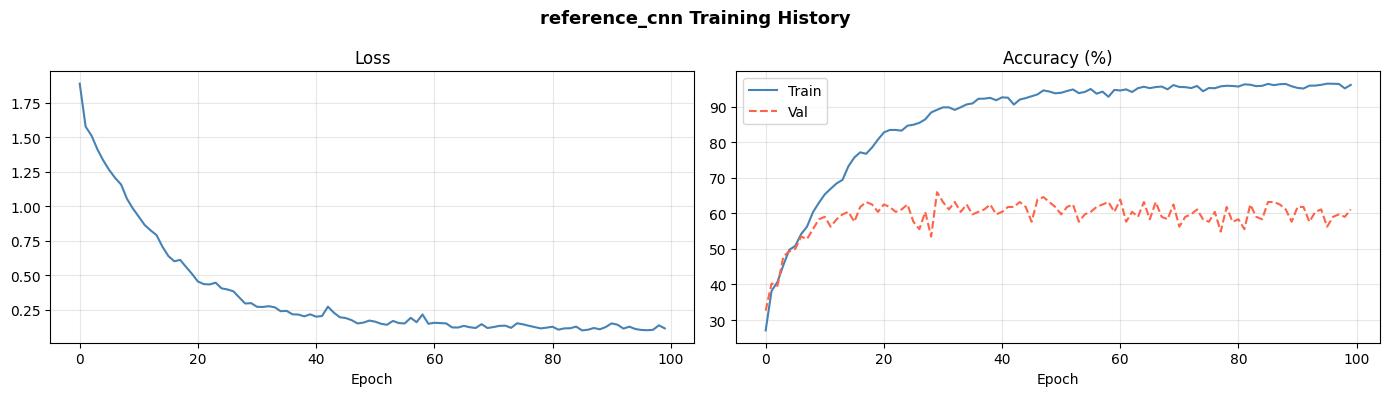

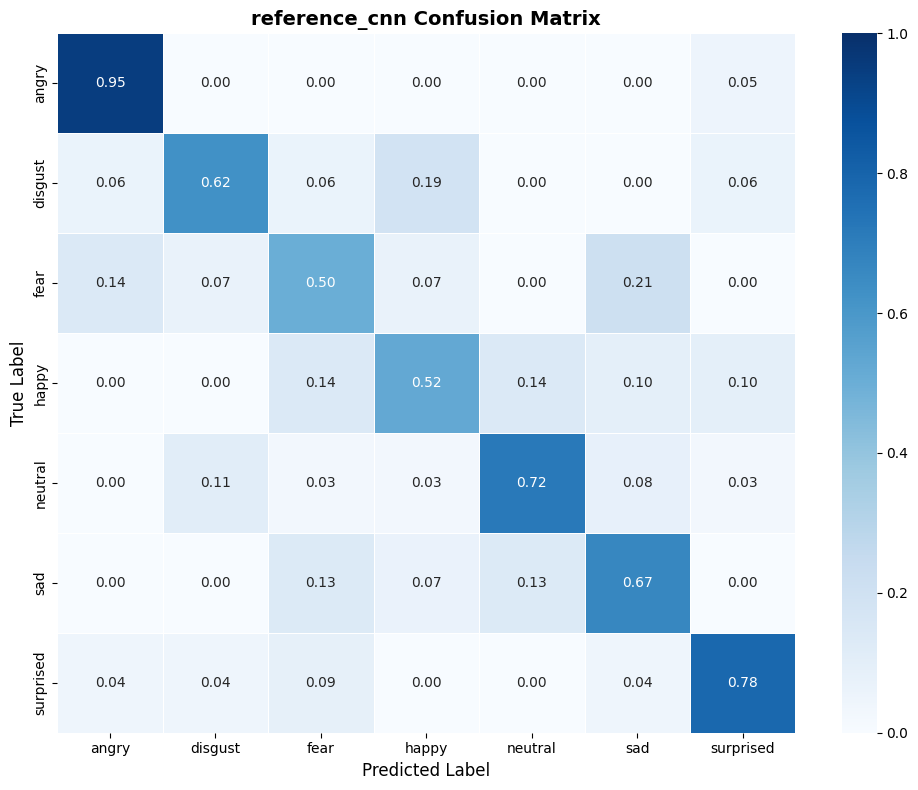

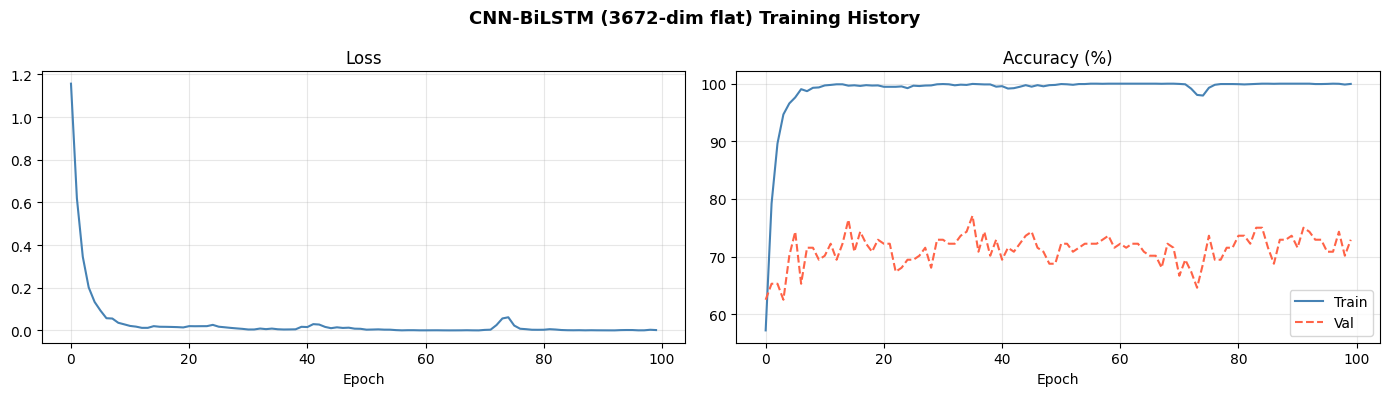

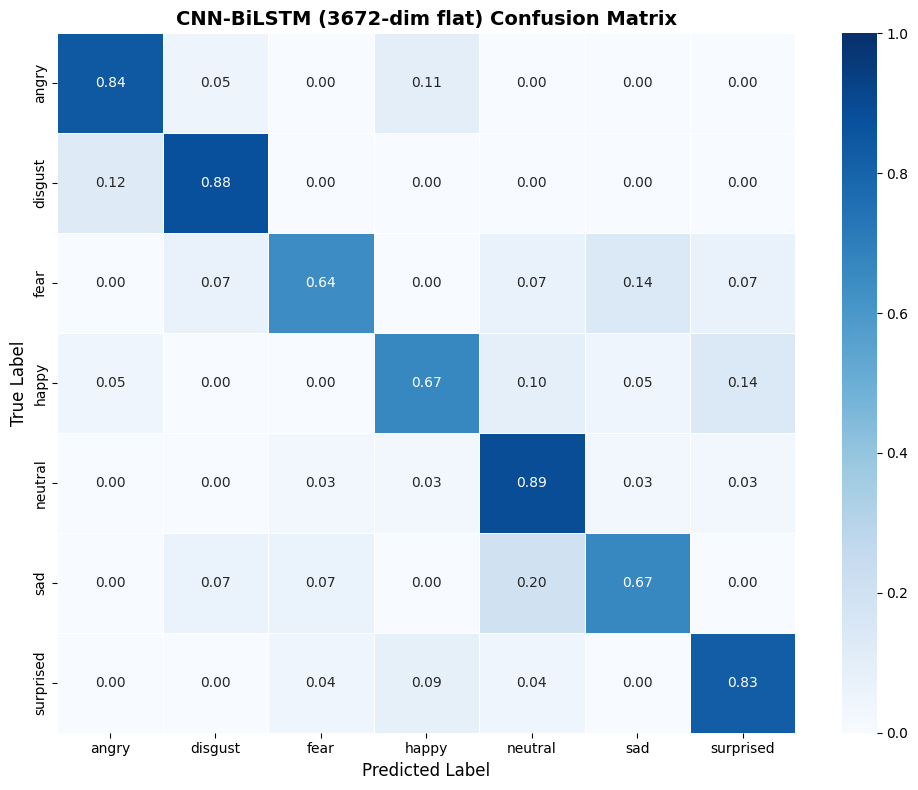

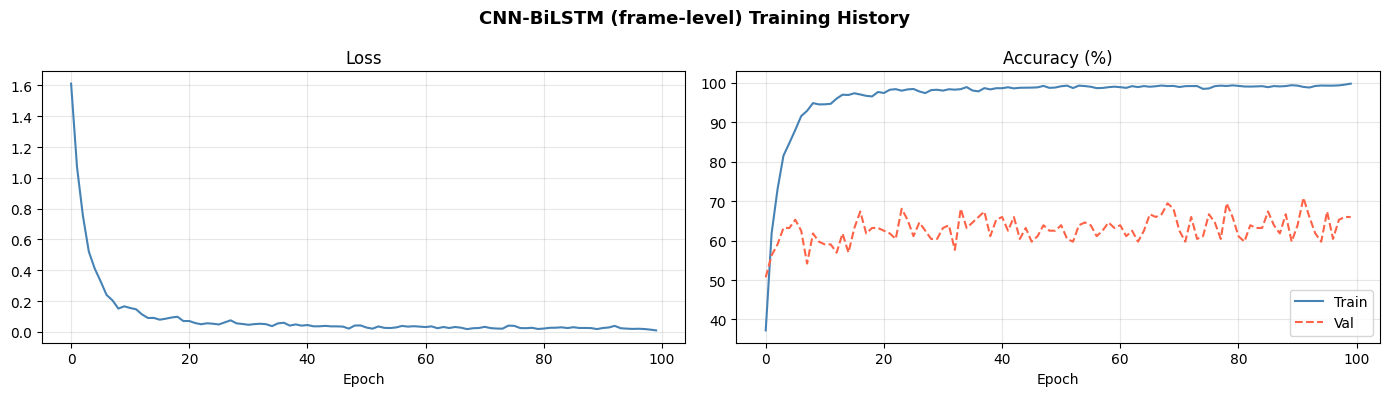

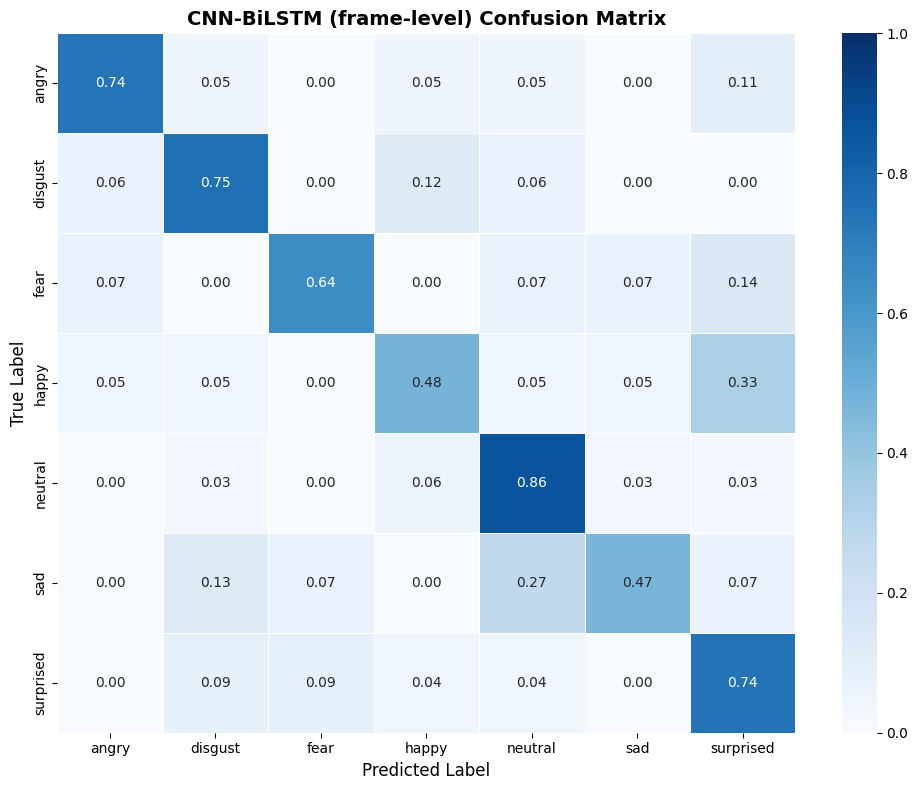

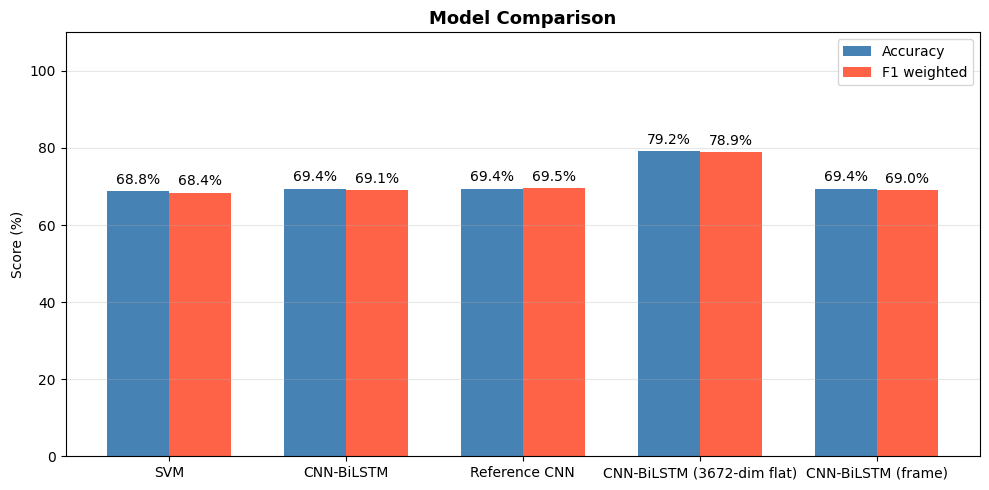

Model                    Accuracy   F1 macro  F1 weighted
--------------------------------------------------------
CNN-BiLSTM (3672-dim flat)     0.7917     0.7763       0.7891
Reference CNN              0.6944     0.6708       0.6954
CNN-BiLSTM                 0.6944     0.6828       0.6911
CNN-BiLSTM (frame)         0.6944     0.6734       0.6897
SVM                        0.6875     0.6536       0.6842


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

if not all_results:
    print('No results yet — train at least one model in Section 6 first')
else:
    names = list(all_results.keys())
    acc   = [all_results[m].get('accuracy', 0) * 100    for m in names]
    f1    = [all_results[m].get('f1_weighted', 0) * 100 for m in names]
    x, w  = np.arange(len(names)), 0.35

    fig, ax = plt.subplots(figsize=(max(8, len(names) * 2), 5))
    b1 = ax.bar(x - w/2, acc, w, label='Accuracy',    color='steelblue')
    b2 = ax.bar(x + w/2, f1,  w, label='F1 weighted', color='tomato')
    ax.bar_label(b1, fmt='%.1f%%', padding=3)
    ax.bar_label(b2, fmt='%.1f%%', padding=3)
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylim(0, 110); ax.set_ylabel('Score (%)')
    ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'{"Model":<22} {"Accuracy":>10} {"F1 macro":>10} {"F1 weighted":>12}')
    print('-' * 56)
    for name in sorted(names, key=lambda n: -all_results[n].get('f1_weighted', 0)):
        m = all_results[name]
        print(f'{name:<22} {m.get("accuracy",0):>10.4f} '
              f'{m.get("f1_macro",0):>10.4f} {m.get("f1_weighted",0):>12.4f}')

## 8. 5-Fold Cross Validation

Provides a more reliable accuracy estimate than a single train/test split.
Each fold trains on 80% and tests on 20%, with no data leakage between folds.
Augmentation is applied to each training fold independently.

Change `CV_MODELS` to select which models to evaluate.
Note: Deep models take ~10 min per fold on T4 GPU.

In [ ]:
# ── CV configuration ──────────────────────────────────────────────────────────
CV_MODELS     = ['paper_cnn_bilstm', 'svm']
K             = 5
CV_EPOCHS     = 100
CV_EARLY_STOP = 9999   # set to e.g. 15 to enable early stopping per fold

print('CV models:', CV_MODELS)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from evaluation.metrics import compute_metrics
from utils.config import EMOTION_TO_IDX

# ── Build full unaugmented dataset for splitting ───────────────────────────────
print('Building full unaugmented dataset for CV...')
X_cv, y_cv = [], []
for path, label in tqdm(samples):
    if label not in EMOTION_TO_IDX:
        continue
    try:
        y_audio = load_and_pad(path)
        X_cv.append(extract_paper_features_mean(y_audio))
        y_cv.append(EMOTION_TO_IDX[label])
    except Exception as e:
        pass

X_cv = np.stack(X_cv).astype(np.float32)
y_cv = np.array(y_cv, dtype=np.int64)
print(f'Full dataset: {X_cv.shape}')

skf        = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
cv_results = {name: [] for name in CV_MODELS}

In [ ]:
# ── CV loop ───────────────────────────────────────────────────────────────────
for model_name in CV_MODELS:
    print(f'\n{"="*60}')
    print(f'  {K}-Fold CV: {model_name}')
    print(f'{"="*60}')

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_cv, y_cv)):
        print(f'\n  Fold {fold+1}/{K}')

        X_te_fold = X_cv[test_idx]
        y_te_fold = y_cv[test_idx]

        if model_name in ('svm', 'lr'):
            # Classical — no augmentation needed, use StandardScaler
            fold_scaler = StandardScaler()
            X_tr_fold   = fold_scaler.fit_transform(X_cv[train_idx])
            X_te_fold   = fold_scaler.transform(X_te_fold)
            from sklearn.svm import SVC
            from sklearn.linear_model import LogisticRegression
            clf = (SVC(C=10, gamma='scale') if model_name == 'svm'
                   else LogisticRegression(C=1.0, max_iter=2000, n_jobs=-1))
            clf.fit(X_tr_fold, y_cv[train_idx])
            preds = clf.predict(X_te_fold)
            m     = compute_metrics(y_te_fold, preds)

        else:
            # Deep model — apply 4x augmentation to train fold
            fold_train_samples = [samples[i] for i in train_idx]
            X_tr_list, y_tr_list = [], []
            for path, label in fold_train_samples:
                if label not in EMOTION_TO_IDX:
                    continue
                idx = EMOTION_TO_IDX[label]
                try:
                    y_audio = load_and_pad(path)
                    for y_aug in [augment_noise(y_audio),
                                  augment_pitch(y_audio),
                                  augment_pitch(augment_noise(y_audio)),
                                  y_audio]:
                        X_tr_list.append(extract_paper_features_mean(y_aug))
                        y_tr_list.append(idx)
                except:
                    pass

            X_tr_fold = np.stack(X_tr_list).astype(np.float32)
            y_tr_fold = np.array(y_tr_list, dtype=np.int64)
            print(f'    Train (aug): {X_tr_fold.shape}  Test: {X_te_fold.shape}')

            num_cls    = len(set(y_tr_fold.tolist()))
            import importlib, models.paper_cnn_bilstm as m_mod
            importlib.reload(m_mod)
            from models.paper_cnn_bilstm import PaperCNNBiLSTM
            fold_model = PaperCNNBiLSTM(
                input_features=X_tr_fold.shape[1], num_classes=num_cls
            ).to(device)

            criterion  = weighted_criterion(torch.tensor(y_tr_fold), num_cls, device)
            optimizer  = Adam(fold_model.parameters(), lr=1e-3, weight_decay=1e-6)
            scheduler  = ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                            patience=5, min_lr=1e-5)
            fold_dl    = DataLoader(FlatFeatureDataset(X_tr_fold, y_tr_fold),
                                    batch_size=64, shuffle=True, num_workers=2)
            fold_te_dl = DataLoader(FlatFeatureDataset(X_te_fold, y_te_fold),
                                    batch_size=64, shuffle=False, num_workers=2)
            best_acc      = 0.0
            patience_left = CV_EARLY_STOP
            ckpt_path     = f'{CHECKPOINT_DIR}/cv_{model_name}_fold{fold+1}.pt'

            for epoch in range(1, CV_EPOCHS + 1):
                fold_model.train()
                train_correct = train_total = 0
                for xb, yb in fold_dl:
                    xb, yb = xb.to(device), yb.to(device)
                    optimizer.zero_grad()
                    out  = fold_model(xb)
                    loss = criterion(out, yb)
                    loss.backward()
                    optimizer.step()
                    train_correct += (out.argmax(1) == yb).sum().item()
                    train_total   += len(yb)

                fold_model.eval()
                val_correct = val_total = 0
                with torch.no_grad():
                    for xb, yb in fold_te_dl:
                        xb, yb = xb.to(device), yb.to(device)
                        val_correct += (fold_model(xb).argmax(1) == yb).sum().item()
                        val_total   += len(yb)

                train_acc = train_correct / train_total
                val_acc   = val_correct   / val_total
                scheduler.step(val_acc)

                if val_acc > best_acc:
                    best_acc      = val_acc
                    patience_left = CV_EARLY_STOP
                    torch.save({'model_state': fold_model.state_dict()}, ckpt_path)
                else:
                    patience_left -= 1
                    if patience_left == 0:
                        print(f'    Early stopping at epoch {epoch}')
                        break

                if epoch % 10 == 0:
                    print(f'    Epoch {epoch:3d}  train={train_acc:.4f}  '
                          f'val={val_acc:.4f}  best={best_acc:.4f}')

            ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
            fold_model.load_state_dict(ckpt['model_state'])
            fold_model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for xb, yb in fold_te_dl:
                    preds.extend(fold_model(xb.to(device)).argmax(1).cpu().numpy())
                    labels.extend(yb.numpy())
            m = compute_metrics(np.array(labels), np.array(preds))

        acc = m['accuracy']
        f1  = m['f1_weighted']
        cv_results[model_name].append({'accuracy': acc, 'f1_weighted': f1})
        print(f'    Fold {fold+1} — accuracy={acc:.4f}  f1={f1:.4f}')

In [ ]:
# ── CV Summary ────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  {K}-FOLD CV SUMMARY')
print(f'{"="*60}')
print(f'{"Model":<22} {"Mean Acc":>10} {"Std":>8} {"Mean F1":>10} {"Std":>8}')
print('-' * 60)
for name, scores in cv_results.items():
    accs = [s['accuracy']    for s in scores]
    f1s  = [s['f1_weighted'] for s in scores]
    print(f'{name:<22} {np.mean(accs):>10.4f} {np.std(accs):>8.4f} '
          f'{np.mean(f1s):>10.4f} {np.std(f1s):>8.4f}')
    print(f'  Per fold: {[f"{a:.4f}" for a in accs]}')

## 9. Predict on Your Own Audio

In [ ]:
# ── Choose which model to use for prediction ──────────────────────────────────
PREDICT_WITH = 'paper_cnn_bilstm'   # must have been trained in Section 6

from google.colab import files
import IPython.display as ipd

uploaded   = files.upload()   # upload a .wav file
audio_path = list(uploaded.keys())[0]
print('Uploaded:', audio_path)
ipd.display(ipd.Audio(audio_path))

In [ ]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils.config import IDX_TO_EMOTION

if PREDICT_WITH in ('svm', 'lr'):
    from models.baseline import load_baseline
    bl      = load_baseline(f'{CHECKPOINT_DIR}/{PREDICT_WITH}_baseline.pkl')
    feat    = extract_paper_features_mean(load_and_pad(audio_path))
    probs   = bl.predict_proba(feat.reshape(1, -1)).squeeze()
    present_indices = sorted(set(y_train.tolist()))
    present_names   = [IDX_TO_EMOTION[i] for i in present_indices]

else:
    import importlib, models.paper_cnn_bilstm as m_mod
    importlib.reload(m_mod)
    from models.paper_cnn_bilstm import PaperCNNBiLSTM

    ckpt      = torch.load(f'{CHECKPOINT_DIR}/{PREDICT_WITH}_best.pt',
                            map_location=device, weights_only=False)
    pred_model = PaperCNNBiLSTM(
        input_features=ckpt['input_features'],
        num_classes=ckpt['num_classes']
    ).to(device)
    pred_model.load_state_dict(ckpt['model_state'])
    pred_model.eval()

    feat    = extract_paper_features_mean(load_and_pad(audio_path))
    x_in    = torch.tensor(feat.reshape(1, -1), dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = torch.softmax(pred_model(x_in), dim=1).squeeze().cpu().numpy()

    present_indices = sorted(set(y_train.tolist()))
    present_names   = [IDX_TO_EMOTION[i] for i in present_indices]

pred_emotion = present_names[probs.argmax()]
confidence   = probs.max()
print(f'\nPredicted : {pred_emotion.upper()}')
print(f'Confidence: {confidence*100:.1f}%')

order        = np.argsort(probs)[::-1]
sorted_names = [present_names[i] for i in order]
sorted_probs = probs[order]
bar_colors   = ['gold' if n == pred_emotion else 'steelblue' for n in sorted_names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_names, sorted_probs * 100, color=bar_colors)
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlim(0, 115)
ax.set_xlabel('Probability (%)')
ax.set_title(f'Emotion Prediction — {PREDICT_WITH}', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()